In [1]:
!pip install pandas



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install numpy 



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install seaborn



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install scikit-learn



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
!pip install streamlit flask



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
df = pd.read_csv("house_prices_srilanka.csv")
print("Dataset Shape (Rows, Columns):")
df.shape


Dataset Shape (Rows, Columns):


(20000, 14)

In [8]:
print("Column Names:")
df.columns


Column Names:


Index(['district', 'area', 'perch', 'bedrooms', 'bathrooms',
       'kitchen_area_sqft', 'parking_spots', 'has_garden', 'has_ac',
       'water_supply', 'electricity', 'floors', 'year_built', 'price_lkr'],
      dtype='object')

In [9]:
df.head()


,district,area,perch,bedrooms,bathrooms,kitchen_area_sqft,parking_spots,has_garden,has_ac,water_supply,electricity,floors,year_built,price_lkr
0,Polonnaruwa,Polonnaruwa Central,14,5,4,112,2,False,False,Pipe-borne,Single phase,1,2022,16236332
1,Matale,Matale Central,26,7,5,250,2,True,False,Both,Single phase,3,1987,33907509
2,Mullaitivu,Mullaitivu Central,7,3,2,77,2,True,True,Well,Single phase,1,1988,5954312
3,Anuradhapura,New Town,2,2,2,39,1,True,True,Both,Three phase,2,2024,5177534
4,Batticaloa,Batticaloa Town,20,5,4,117,1,True,True,Well,Single phase,1,1995,20182409


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   district           20000 non-null  object
 1   area               20000 non-null  object
 2   perch              20000 non-null  int64 
 3   bedrooms           20000 non-null  int64 
 4   bathrooms          20000 non-null  int64 
 5   kitchen_area_sqft  20000 non-null  int64 
 6   parking_spots      20000 non-null  int64 
 7   has_garden         20000 non-null  bool  
 8   has_ac             20000 non-null  bool  
 9   water_supply       20000 non-null  object
 10  electricity        20000 non-null  object
 11  floors             20000 non-null  int64 
 12  year_built         20000 non-null  int64 
 13  price_lkr          20000 non-null  int64 
dtypes: bool(2), int64(8), object(4)
memory usage: 1.9+ MB


In [11]:
target_variable = "price_lkr"
print("Target Variable:", target_variable)


Target Variable: price_lkr


In [12]:
categorical_features = [
    "district",
    "area",
    "water_supply",
    "electricity"
]

binary_features = [
    "has_garden",
    "has_ac"
]

numerical_features = [
    "perch",
    "bedrooms",
    "bathrooms",
    "kitchen_area_sqft",
    "parking_spots",
    "floors",
    "year_built"
]

print("Categorical Features:", categorical_features)
print("Binary Features:", binary_features)
print("Numerical Features:", numerical_features)


Categorical Features: ['district', 'area', 'water_supply', 'electricity']
Binary Features: ['has_garden', 'has_ac']
Numerical Features: ['perch', 'bedrooms', 'bathrooms', 'kitchen_area_sqft', 'parking_spots', 'floors', 'year_built']


In [13]:
feature_summary = pd.DataFrame({
    "Feature": categorical_features + binary_features + numerical_features + [target_variable],
    "Type": (
        ["Categorical"] * len(categorical_features) +
        ["Binary"] * len(binary_features) +
        ["Numerical"] * len(numerical_features) +
        ["Target"]
    )
})

feature_summary


,Feature,Type
0,district,Categorical
1,area,Categorical
2,water_supply,Categorical
3,electricity,Categorical
4,has_garden,Binary
5,has_ac,Binary
6,perch,Numerical
7,bedrooms,Numerical
8,bathrooms,Numerical
9,kitchen_area_sqft,Numerical


In [14]:
print("Dataset Overview:")
df.info()


Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   district           20000 non-null  object
 1   area               20000 non-null  object
 2   perch              20000 non-null  int64 
 3   bedrooms           20000 non-null  int64 
 4   bathrooms          20000 non-null  int64 
 5   kitchen_area_sqft  20000 non-null  int64 
 6   parking_spots      20000 non-null  int64 
 7   has_garden         20000 non-null  bool  
 8   has_ac             20000 non-null  bool  
 9   water_supply       20000 non-null  object
 10  electricity        20000 non-null  object
 11  floors             20000 non-null  int64 
 12  year_built         20000 non-null  int64 
 13  price_lkr          20000 non-null  int64 
dtypes: bool(2), int64(8), object(4)
memory usage: 1.9+ MB


In [15]:
print("Summary Statistics for Numerical Features:")
df.describe()


Summary Statistics for Numerical Features:


,perch,bedrooms,bathrooms,kitchen_area_sqft,parking_spots,floors,year_built,price_lkr
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04
mean,11.510500,3.901600,3.171650,113.718800,1.141100,1.557150,2004.926550,1.598142e+07
std,8.519719,1.839426,1.530883,69.801873,0.939167,0.628135,11.817353,1.338156e+07
min,2.000000,1.000000,1.000000,35.000000,0.000000,1.000000,1985.000000,1.500000e+06
25%,5.000000,2.000000,2.000000,53.000000,0.000000,1.000000,1995.000000,6.591047e+06
50%,10.000000,4.000000,3.000000,95.000000,1.000000,1.000000,2005.000000,1.206384e+07
75%,16.000000,5.000000,5.000000,161.000000,2.000000,2.000000,2015.000000,2.096723e+07
max,80.000000,7.000000,5.000000,250.000000,3.000000,3.000000,2025.000000,1.500321e+08


In [16]:
print("Summary Statistics for Target Variable (price_lkr):")
df["price_lkr"].describe()


Summary Statistics for Target Variable (price_lkr):


count    2.000000e+04
mean     1.598142e+07
std      1.338156e+07
min      1.500000e+06
25%      6.591047e+06
50%      1.206384e+07
75%      2.096723e+07
max      1.500321e+08
Name: price_lkr, dtype: float64

In [17]:
print("Mean House Price (LKR):", df["price_lkr"].mean())
print("Median House Price (LKR):", df["price_lkr"].median())


Mean House Price (LKR): 15981420.1121
Median House Price (LKR): 12063842.0


In [18]:
key_features = [
    "perch",
    "bedrooms",
    "bathrooms",
    "kitchen_area_sqft",
    "year_built"
]

df[key_features].describe()


,perch,bedrooms,bathrooms,kitchen_area_sqft,year_built
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,11.510500,3.901600,3.171650,113.718800,2004.926550
std,8.519719,1.839426,1.530883,69.801873,11.817353
min,2.000000,1.000000,1.000000,35.000000,1985.000000
25%,5.000000,2.000000,2.000000,53.000000,1995.000000
50%,10.000000,4.000000,3.000000,95.000000,2005.000000
75%,16.000000,5.000000,5.000000,161.000000,2015.000000
max,80.000000,7.000000,5.000000,250.000000,2025.000000


In [19]:
print("Missing Values Count per Column:")
df.isnull().sum()


Missing Values Count per Column:


district             0
area                 0
perch                0
bedrooms             0
bathrooms            0
kitchen_area_sqft    0
parking_spots        0
has_garden           0
has_ac               0
water_supply         0
electricity          0
floors               0
year_built           0
price_lkr            0
dtype: int64

In [20]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Values Percentage per Column:")
missing_percentage


Missing Values Percentage per Column:


district             0.0
area                 0.0
perch                0.0
bedrooms             0.0
bathrooms            0.0
kitchen_area_sqft    0.0
parking_spots        0.0
has_garden           0.0
has_ac               0.0
water_supply         0.0
electricity          0.0
floors               0.0
year_built           0.0
price_lkr            0.0
dtype: float64

In [21]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)


Number of Duplicate Rows: 0


In [22]:
if duplicate_count > 0:
    df[df.duplicated()]
else:
    print("No duplicate records found in the dataset.")


No duplicate records found in the dataset.


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


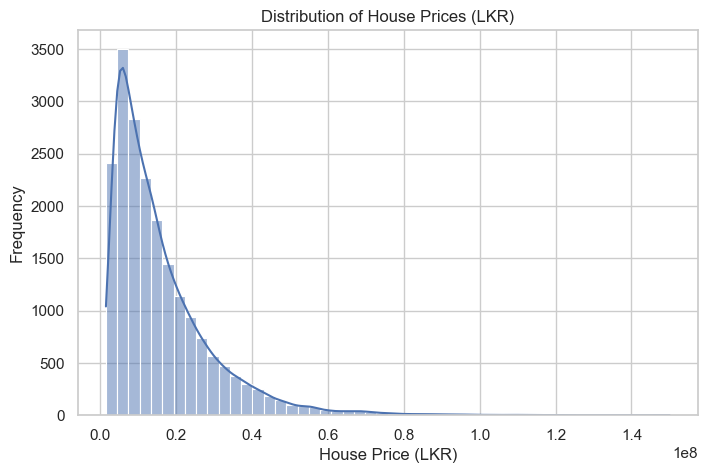

In [24]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price_lkr"], bins=50, kde=True)
plt.title("Distribution of House Prices (LKR)")
plt.xlabel("House Price (LKR)")
plt.ylabel("Frequency")
plt.show()


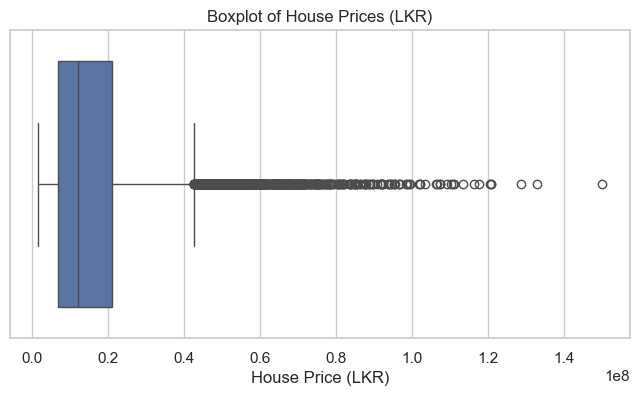

In [25]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["price_lkr"])
plt.title("Boxplot of House Prices (LKR)")
plt.xlabel("House Price (LKR)")
plt.show()


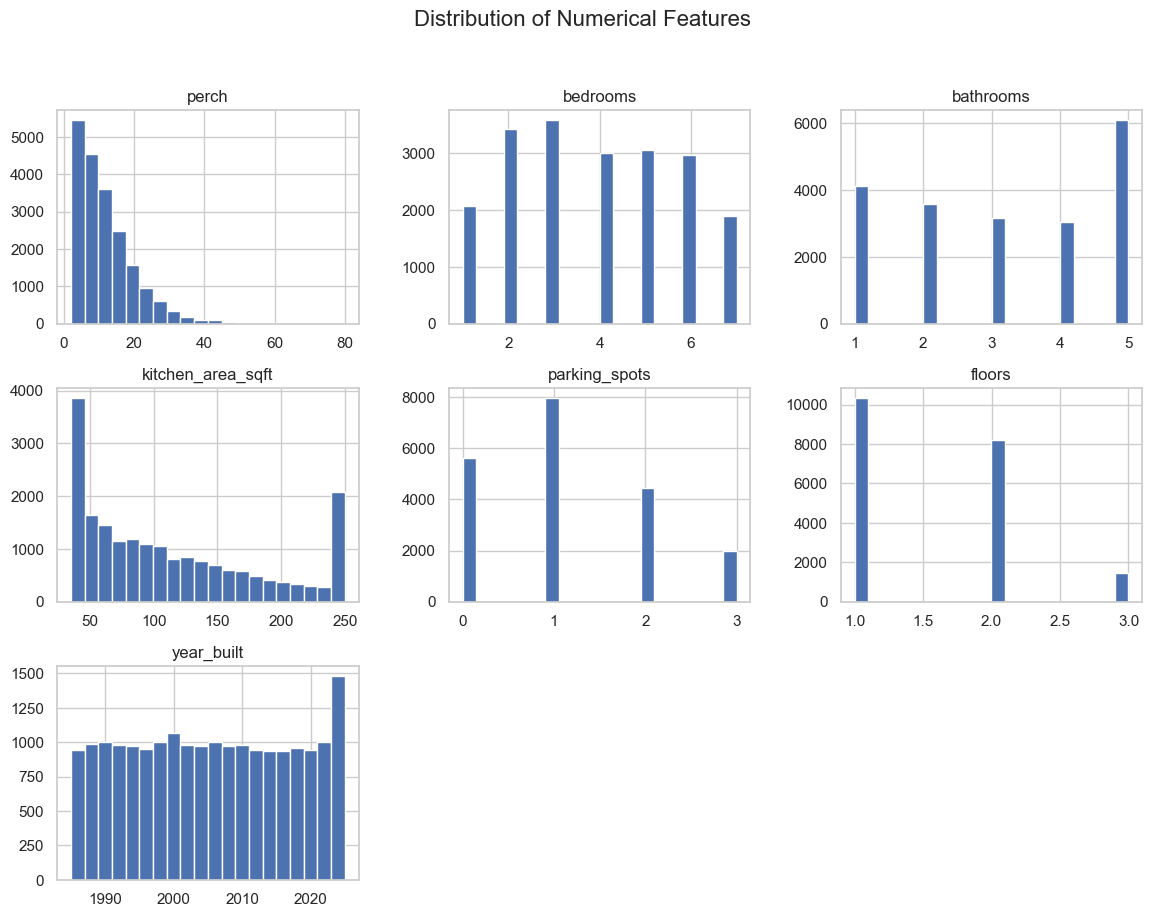

In [26]:
numerical_features = [
    "perch",
    "bedrooms",
    "bathrooms",
    "kitchen_area_sqft",
    "parking_spots",
    "floors",
    "year_built"
]

df[numerical_features].hist(bins=20, figsize=(14, 10))
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()


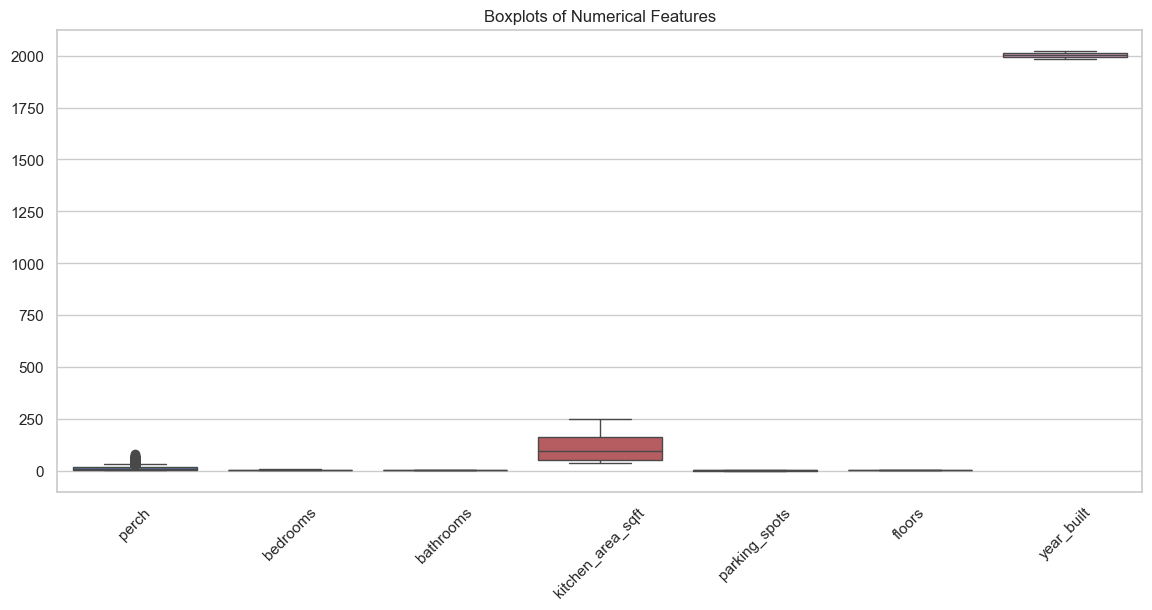

In [27]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[numerical_features])
plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")
plt.show()


In [28]:
df_clean = df.copy()
print("Working copy of dataset created.")


Working copy of dataset created.


In [29]:
df_clean.dtypes


district             object
area                 object
perch                 int64
bedrooms              int64
bathrooms             int64
kitchen_area_sqft     int64
parking_spots         int64
has_garden             bool
has_ac                 bool
water_supply         object
electricity          object
floors                int64
year_built            int64
price_lkr             int64
dtype: object

In [30]:
df_clean.describe()


,perch,bedrooms,bathrooms,kitchen_area_sqft,parking_spots,floors,year_built,price_lkr
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04
mean,11.510500,3.901600,3.171650,113.718800,1.141100,1.557150,2004.926550,1.598142e+07
std,8.519719,1.839426,1.530883,69.801873,0.939167,0.628135,11.817353,1.338156e+07
min,2.000000,1.000000,1.000000,35.000000,0.000000,1.000000,1985.000000,1.500000e+06
25%,5.000000,2.000000,2.000000,53.000000,0.000000,1.000000,1995.000000,6.591047e+06
50%,10.000000,4.000000,3.000000,95.000000,1.000000,1.000000,2005.000000,1.206384e+07
75%,16.000000,5.000000,5.000000,161.000000,2.000000,2.000000,2015.000000,2.096723e+07
max,80.000000,7.000000,5.000000,250.000000,3.000000,3.000000,2025.000000,1.500321e+08


In [31]:
print("Clean Dataset Shape:", df_clean.shape)


Clean Dataset Shape: (20000, 14)


In [32]:
df_clean.to_csv("house_prices_srilanka_cleaned.csv", index=False)
print("Cleaned dataset saved successfully.")


Cleaned dataset saved successfully.


In [33]:
X = df_clean.drop("price_lkr", axis=1)
y = df_clean["price_lkr"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (20000, 13)
Target shape: (20000,)


In [34]:
categorical_features = [
    "district",
    "area",
    "water_supply",
    "electricity"
]

binary_features = [
    "has_garden",
    "has_ac"
]

numerical_features = [
    "perch",
    "bedrooms",
    "bathrooms",
    "kitchen_area_sqft",
    "parking_spots",
    "floors",
    "year_built"
]

print("Categorical:", categorical_features)
print("Binary:", binary_features)
print("Numerical:", numerical_features)


Categorical: ['district', 'area', 'water_supply', 'electricity']
Binary: ['has_garden', 'has_ac']
Numerical: ['perch', 'bedrooms', 'bathrooms', 'kitchen_area_sqft', 'parking_spots', 'floors', 'year_built']


In [35]:
X[binary_features] = X[binary_features].astype(int)

X[binary_features].head()


,has_garden,has_ac
0,0,0
1,1,0
2,1,1
3,1,1
4,1,1


In [36]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

print("Encoded feature shape:", X_encoded.shape)


Encoded feature shape: (20000, 104)


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_encoded[numerical_features] = scaler.fit_transform(
    X_encoded[numerical_features]
)

X_encoded.head()


,perch,bedrooms,bathrooms,kitchen_area_sqft,parking_spots,has_garden,has_ac,floors,year_built,district_Anuradhapura,...,area_Unawatuna,area_Uppuveli,area_Vavuniya Central,area_Wadduwa,area_Wattala,area_Weligama,area_Wellawatte,water_supply_Pipe-borne,water_supply_Well,electricity_Three phase
0,0.292212,0.597158,0.541106,-0.024625,0.914557,0,0,-0.887013,1.444814,False,...,False,False,False,False,False,False,False,True,False,False
1,1.700744,1.684481,1.194340,1.952449,0.914557,1,0,2.297095,-1.517006,False,...,False,False,False,False,False,False,False,False,False,False
2,-0.529432,-0.490165,-0.765362,-0.526056,0.914557,1,1,-0.887013,-1.432383,False,...,False,False,False,False,False,False,False,False,True,False
3,-1.116321,-1.033827,-0.765362,-1.070468,-0.150243,1,1,0.705041,1.614061,True,...,False,False,False,False,False,False,False,False,False,True
4,0.996478,0.597158,0.541106,0.047009,-0.150243,1,1,-0.887013,-0.840019,False,...,False,False,False,False,False,False,False,False,True,False


In [38]:
print("Final feature matrix shape:", X_encoded.shape)
X_encoded.info()


Final feature matrix shape: (20000, 104)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Columns: 104 entries, perch to electricity_Three phase
dtypes: bool(95), float64(7), int64(2)
memory usage: 3.2 MB


In [39]:
X_encoded.to_csv("X_prepared.csv", index=False)
y.to_csv("y_target.csv", index=False)

print("Encoded & scaled datasets saved successfully.")


Encoded & scaled datasets saved successfully.


In [40]:
from sklearn.model_selection import train_test_split


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)


In [42]:
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)


Training features shape: (16000, 104)
Testing features shape: (4000, 104)
Training target shape: (16000,)
Testing target shape: (4000,)


In [43]:
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Train-test datasets saved successfully.")


Train-test datasets saved successfully.


In [44]:
from sklearn.linear_model import LinearRegression


In [45]:
linear_model = LinearRegression()


In [46]:
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")


Linear Regression model trained successfully.


In [47]:
print("Number of features used:", linear_model.coef_.shape[0])


Number of features used: 104


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


In [49]:
y_pred = linear_model.predict(X_test)

print("Predictions generated successfully.")


Predictions generated successfully.


In [50]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:,.2f} LKR")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f} LKR")
print(f"R² Score: {r2:.4f}")


Model Evaluation Metrics:
Mean Absolute Error (MAE): 2,905,625.38 LKR
Mean Squared Error (MSE): 21,861,773,569,369.77
Root Mean Squared Error (RMSE): 4,675,657.55 LKR
R² Score: 0.8771


In [51]:
print("Evaluation Interpretation:")
print("- MAE shows the average absolute prediction error in LKR.")
print("- RMSE penalizes larger errors more heavily.")
print("- R² indicates how much variance in house prices is explained by the model.")


Evaluation Interpretation:
- MAE shows the average absolute prediction error in LKR.
- RMSE penalizes larger errors more heavily.
- R² indicates how much variance in house prices is explained by the model.


In [52]:
comparison_df = pd.DataFrame({
    "Actual Price (LKR)": y_test.values[:10],
    "Predicted Price (LKR)": y_pred[:10]
})

comparison_df


,Actual Price (LKR),Predicted Price (LKR)
0,46231354,3.822978e+07
1,5513160,3.028086e+06
2,19637811,2.582382e+07
3,4803237,1.412260e+07
4,37051512,3.837969e+07
5,6903311,7.028020e+06
6,74905676,5.738453e+07
7,16452205,1.806771e+07
8,14115656,1.998121e+07
9,23137943,2.809083e+07


In [53]:
new_house = {
    "district": "Colombo",
    "area": "Wellawatte",
    "perch": 10,
    "bedrooms": 3,
    "bathrooms": 2,
    "kitchen_area_sqft": 90,
    "parking_spots": 1,
    "has_garden": True,
    "has_ac": True,
    "water_supply": "Pipe-borne",
    "electricity": "Three phase",
    "floors": 1,
    "year_built": 2015
}

new_house_df = pd.DataFrame([new_house])
new_house_df


,district,area,perch,bedrooms,bathrooms,kitchen_area_sqft,parking_spots,has_garden,has_ac,water_supply,electricity,floors,year_built
0,Colombo,Wellawatte,10,3,2,90,1,True,True,Pipe-borne,Three phase,1,2015


In [54]:
# Convert binary values
new_house_df[binary_features] = new_house_df[binary_features].astype(int)

# One-hot encode categorical features
new_house_encoded = pd.get_dummies(
    new_house_df,
    columns=categorical_features,
    drop_first=True
)

# Align columns with training data
new_house_encoded = new_house_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

# Scale numerical features
new_house_encoded[numerical_features] = scaler.transform(
    new_house_encoded[numerical_features]
)

new_house_encoded


,perch,bedrooms,bathrooms,kitchen_area_sqft,parking_spots,has_garden,has_ac,floors,year_built,district_Anuradhapura,...,area_Unawatuna,area_Uppuveli,area_Vavuniya Central,area_Wadduwa,area_Wattala,area_Weligama,area_Wellawatte,water_supply_Pipe-borne,water_supply_Well,electricity_Three phase
0,-0.177299,-0.490165,-0.765362,-0.33981,-0.150243,1,1,-0.887013,0.85245,0,...,0,0,0,0,0,0,0,0,0,0


In [55]:
predicted_price = linear_model.predict(new_house_encoded)

print(f"Predicted House Price: {predicted_price[0]:,.2f} LKR")


Predicted House Price: 15,003,341.79 LKR


In [56]:
import pickle

# Save model
with open("model.pkl", "wb") as f:
    pickle.dump(linear_model, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save column order
with open("X_columns.pkl", "wb") as f:
    pickle.dump(X_encoded.columns, f)

print("Model, scaler, and columns saved successfully.")


Model, scaler, and columns saved successfully.


In [57]:
!pip install scikit-learn pandas numpy



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


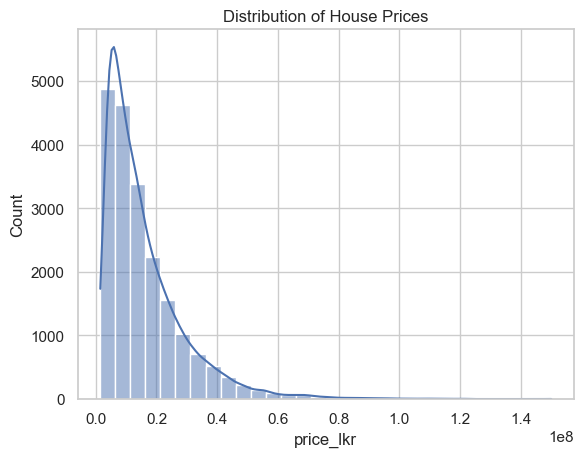

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["price_lkr"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.show()


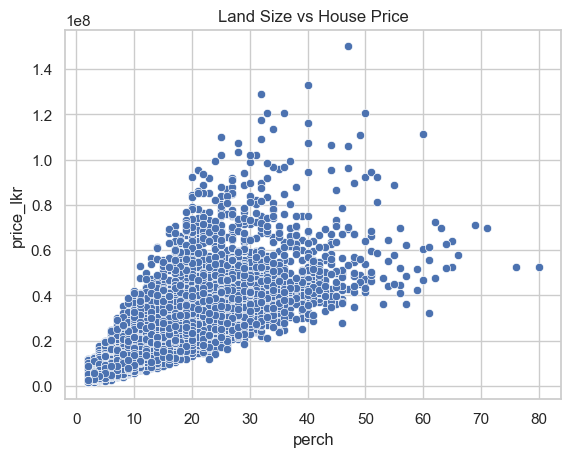

In [59]:
sns.scatterplot(x="perch", y="price_lkr", data=df)
plt.title("Land Size vs House Price")
plt.show()


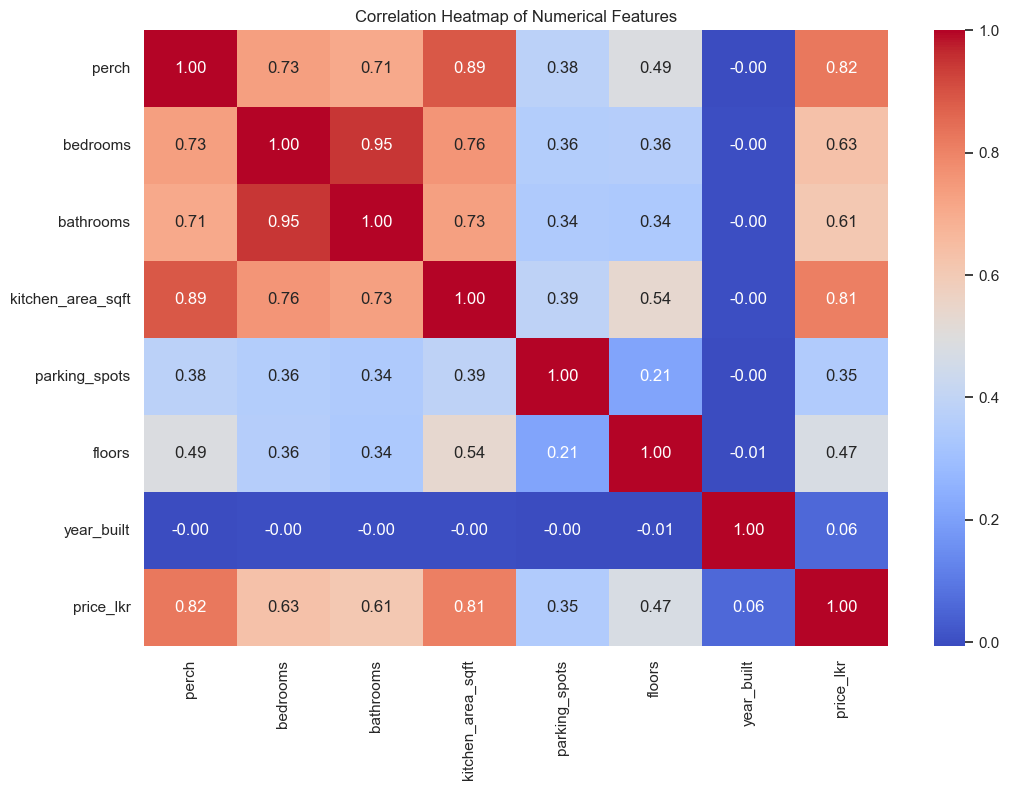

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns
numerical_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12, 8))
sns.heatmap(
    numerical_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


In [61]:
comparison = pd.DataFrame({
    "Actual": y_test[:5],
    "Predicted": y_pred[:5]
})
comparison


,Actual,Predicted
10650,46231354,3.822978e+07
2041,5513160,3.028086e+06
8668,19637811,2.582382e+07
1114,4803237,1.412260e+07
13902,37051512,3.837969e+07
